# TME ROBOTIQUE ET APPRENTISSAGE
## Optimisation multi-objectif

Version étudiant 2025-2026

*mise à jour: 31/03/2026*

Ce notebook peut être exécuté dans [Google Colab](colab.research.google.com/)

Vous devez déposer votre travail sur Moodle:
* déposer votre notebook, avec le nom de fichier *obligatoirement* au format suivant: **RA_NOM1_NOM2.ipynb**
* toutes les cellules exécutées
* des graphes et un commentaire sur les résultats obtenus
* affichage limité au nécessaire pour assurer la lisibilité du notebook (pas d'affichage de debug ni de centaines de graphes !)

*Le sujet est à faire en binome.*

### COMPLETEZ LES CHAMPS CI-DESSOUS AVEC NOM/PRENOM/CARTE_ETU:

* Étudiant 1: **_ZHANG_ _Yuxiang_ 21202829**
* Étudiant 2: **_Alsafadi_ _Kenan_ _21502362_**

## 1. Introduction

Dans ce TME, vous allez mettre en oeuvre des algorithmes évolutionnistes multi-objectifs.

La cellule suivante se charge d'installer les dépendances:

In [1]:
!pip install deap
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [2]:
# à exécuter pour pouvoir tracer les courbes demandées
import matplotlib.pyplot as plt

# pour que les figures apparaissent directement dans le notebook
%matplotlib inline

import random
# ne pas oublier d'initialiser la graine aléatoire...
random.seed()

## 2. Fonctionnement de DEAP

Dans ce TME et les deux prochains, vous allez utiliser DEAP. DEAP est une bibliothèque de prtotypage rapide d'algorithme évolutionnistes. Elle permet de travailler à plusieurs niveaux, depuis l'implémentation complète de l'algorithme à partir de briques de base déjà définies (briques de croisement, mutation, sélection, etc.) jusqu'à l'utilisation boite noire d'un algorithme entièrement implémenté.

Dans ce TME, nous allons construire à la main différents algorithmes à partir de briques de bases et comparer leurs performances sur des cas simples.

On présente dans cette partie le fonctionnement de DEAP, en construisant un algorithme complet à partir de différentes briques disponibles. On rappelle ci-dessous la structure d'un algorithme évolutionniste:

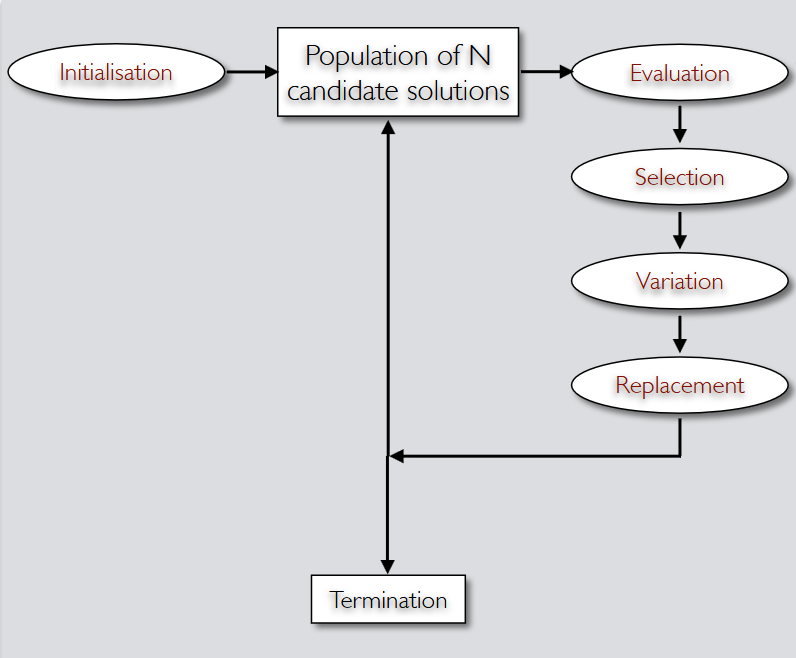

### 2.1. Toolbox et creator

DEAP fonctionne avec une "toolbox" qui permet d'enregistrer et de réutiliser plein de fonctions que nous allons définir.

On peut initialiser la toolbox, y placer une fonction sous un nom qu'on choisit, et l'appeler comme suit:

In [3]:
# On définit une fonction qui sera utilisée par la toolbox
def ma_fonction(x):
    return x**2

In [4]:
from deap import base

# On initialise la toolbox
toolbox = base.Toolbox()

# On ajoute la fonction à la toolbox, on peut l'enregistrer sous n'importe quel nom
toolbox.register("fonction_carre", ma_fonction)

# On peut maintenant utiliser la fonction à travers la toolbox
print(toolbox.fonction_carre(2))

4


De manière analogue à la toolbox, DEAP utilise un objet "creator" qui sert à définir rapidement des classes héritant de classes préexistantes.

Par exemple, l'instruction suivante permet de définir une classe `NamedList` qui hérite de la classe `list` et pour laquelle on ajoute un attribut `tag` de type `str`:

In [5]:
from deap import creator

# Définition d'une classe "NamedList" qui hérite de list et qui a un attribut "tag" de type str
creator.create("NamedList", list, tag=str)

# Instanciation d'un objet de la classe "NamedList"
named_list = creator.NamedList()

# On peut accéder à l'attribut "tag" de l'objet "named_list", et utiliser la classe "NamedList" comme une liste normale
print(type(named_list.tag))
print(named_list)

<class 'str'>
[]


### 2.2. Définir une population

Avec ces deux outils, nous pouvons définir une population.

Pour définir une population, nous devons:
1. Définir les valeurs que peuvent prendre les attributs qui composent le génotype (type de données, intervalle de valeur)
2. Définir ce qu'est le génotype d'un individu (quelle structure de données, nombre d'attributs)
3. Définir la taille de la population (= nombre d'individus)

In [6]:
from deap import tools
import random

MIN_V = -5
MAX_V = 5
IND_SIZE = 10

# Définition d'une classe "FitnessMin" qui hérite de base.Fitness et qui a un attribut "weights" égal à (-1.0,)
# Les weights à (-1.0,) indiquent que nous cherchons à minimiser la fonction de fitness, et qu'on a un seul objectif à minimiser
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

# Retourne une valeur aléatoire entre MIN_V et MAX_V
toolbox.register('attribute', random.uniform, MIN_V, MAX_V)

# On définit un individu comme une liste de valeurs, et on lui associe une fonction de fitness
# base.Fitness est une classe de base pour les fonctions de fitness
creator.create("Individual", list, fitness=creator.FitnessMin)

# Retourne un objet creator.Individual avec IND_SIZE attributs initialisés avec la fonction "attribute" de la toolbox
# initRepeat est une fonction qui permet de répéter une fonction un certain nombre de fois pour remplir une structure de données (ici, une liste)
toolbox.register("individual", tools.initRepeat, creator.Individual,
                 toolbox.attribute, n=IND_SIZE)

# Retourne une liste d'objets creator.Individual échantillonnés aléatoirement en utilisant la fonction "individual"
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

On peut maintenant utiliser la fonction `population` de la toolbox pour initialiser une population:

In [7]:
pop = toolbox.population(n=3)

# On affiche la taille de la population, qui est de 3 individus
print(f"Taille de la population: {len(pop)}")

# On affiche le premier individu de la population
# On peut voir que c'est une liste de 10 valeurs aléatoires entre -5 et 5
print(f"Génotype du premier individu: {pop[0]}")

# La fitness n'est pas encore évaluée, elle est donc vide
print(f"Fitness du premier individu: {pop[0].fitness}")

Taille de la population: 3
Génotype du premier individu: [3.710291784849428, -3.8347812189195807, -1.962256113143137, -4.386193026351214, 0.15386242864128796, 3.1344221539472166, 4.797810189925173, 2.1922407655686227, 2.940300914135019, 1.1932646803527387]
Fitness du premier individu: ()


### 2.3. Mutations et crossover

DEAP fournit plusieurs opérateurs de mutation et crossover, qui sont listés ici: https://deap.readthedocs.io/en/master/api/tools.html#operators

Dans ce TME, nous allons utiliser:
- l'opérateur `cxSimulatedBinaryBounded` qui fait un croisement des parent en prenant des valeurs interpolées entre les valeurs des deux parents
- l'opérateur `mutPolynomialBounded` qui fait des mutations indépendantes des valeurs pour un individu donné

La cellule suivante permet de les ajouter à la toolbox sous les noms `mate` et `mutate`:

In [8]:
toolbox.register("mate", tools.cxSimulatedBinaryBounded,
                 eta=15, low=MIN_V, up=MAX_V)

toolbox.register("mutate", tools.mutPolynomialBounded,
                 eta=15, low=MIN_V, up=MAX_V, indpb=1/IND_SIZE)

On peut maintenant appliquer ces opérateurs à notre population:

In [9]:
ind = pop[0]
print(f"Génotype avant mutation: {ind}")
toolbox.mutate(ind)
print(f"Génotype après mutation: {ind}")

Génotype avant mutation: [3.710291784849428, -3.8347812189195807, -1.962256113143137, -4.386193026351214, 0.15386242864128796, 3.1344221539472166, 4.797810189925173, 2.1922407655686227, 2.940300914135019, 1.1932646803527387]
Génotype après mutation: [3.710291784849428, -3.8347812189195807, -1.962256113143137, -4.386193026351214, 0.15386242864128796, 2.7989050314267567, 4.797810189925173, 2.1922407655686227, 2.80713960729557, 1.1932646803527387]


In [10]:
ind1, ind2 = pop[0], pop[1]
print(f"Génotype du premier individu avant crossover: {ind1}")
print(f"Génotype du deuxième individu avant crossover: {ind2}")
toolbox.mate(ind1, ind2)
print(f"Génotype du premier individu après crossover: {ind1}")
print(f"Génotype du deuxième individu après crossover: {ind2}")

Génotype du premier individu avant crossover: [3.710291784849428, -3.8347812189195807, -1.962256113143137, -4.386193026351214, 0.15386242864128796, 2.7989050314267567, 4.797810189925173, 2.1922407655686227, 2.80713960729557, 1.1932646803527387]
Génotype du deuxième individu avant crossover: [-3.6064001923399647, -3.0711120283799795, 3.3678733075124914, -1.9025654363715105, -1.4399446455535845, -3.592460845908162, 0.5258736496596121, 0.7861465071702787, 0.7990626842815454, -3.658230902140004]
Génotype du premier individu après crossover: [3.7876431453251778, -3.8347812189195807, 3.2739931016449875, -4.386193026351214, -1.4305739200438454, 2.7989050314267567, 4.797810189925173, 2.1922407655686227, 2.80713960729557, -3.669058310962297]
Génotype du deuxième individu après crossover: [-3.684226566514835, -3.0711120283799795, -1.8684139867480665, -1.9025654363715105, 0.14449170313158677, -3.592460845908162, 0.5258736496596121, 0.7861465071702787, 0.7990626842815454, 1.2041683458815964]


### 2.4. Evaluation

L'évaluation correspond au calcul de la ou des fitness (en multi-objectifs) d'un individu. C'est une fonction qui est une donnée du problème et non pas une partie de l'algorithme pour résoudre ce problème. DEAP fournit des exemples de fonctions d'évaluation de benchmark que l'on va utiliser pour comparer différents algorithmes.

Dans la première partie du TME, nous allons utiliser la fonction de Ackley: https://en.wikipedia.org/wiki/Ackley_function
Comme la fonction de Ackley est une fonction à minimiser, on peut bien utiliser nos individus construits avec FitnessMin.

In [11]:
from deap.benchmarks import ackley

# On enregistre la fonction ackley dans la toolbox, en lui donnant le nom "evaluate"
toolbox.register("evaluate", ackley)

On peut maintenant appliquer de manière itérative la fonction d'évaluation sur toute la population et afficher les fitness obtenues:

In [12]:
# Evaluation des individus de la population
fitnesses = list(map(toolbox.evaluate, pop))

# Il faut ensuite assigner les valeurs de fitness à chaque individu de la population
for ind, fit in zip(pop, fitnesses):
    ind.fitness.values = fit

# Affichage ds fitness obtenues pour chaque individu de la population
for ind in pop:
    print(f"Fitness: {ind.fitness.values}")

Fitness: (11.683359978279691,)
Fitness: (8.522380892367021,)
Fitness: (10.956869587373657,)


### 2.5. Sélection

Comme pour les opérateurs de mutation et croisement, les opérateurs de sélections implémentés dans DEAP sont listés ici: https://deap.readthedocs.io/en/master/api/tools.html#operators

Dans ce TME, nous allons utiliser trois opérateurs de sélection:
- `selTournament` qui tire au hasard `tournsize` individus de la population et sélectionne le meilleur individu du "tournoi", et reproduit l'opération jusqu'à avoir sélectionner `k` individus. Avec ce système, il est possible qu'un individu soit sélectionné plusieurs fois si il est tiré au sort dans différents "tournois" et les remportent.
- `selBest` qui prend simplement les `k` meilleurs individus parmi la population
- `selNSGA2` qui opère une sélection multi-objectifs en prenant les individus se situant sur les fronts de pareto.


La cellule suivant présente un exemple d'utilisation de `selBest`:

In [13]:
offspring = tools.selBest(pop, k=2)

# On voit qu'on a sélectionné les 2 meilleurs individus de la population
# Comme la fonction de fitness est à minimiser, les individus sélectionnés sont ceux qui ont les plus petites valeurs de fitness
for ind in offspring:
    print(f"Fitness: {ind.fitness.values}")

Fitness: (8.522380892367021,)
Fitness: (10.956869587373657,)


## 3. Prise en main

A partir du petit tutoriel qu'on vient de faire, vous allez maintenant implémenter trois algorithmes complets et comparer leurs performances sur la minimisation de la fonction de Ackley.

### 3.1. Sélection par tournoi


#### Question 1.

Pour commencez, complétez la fonction ci-dessous qui définit un algorithme évolutionniste avec les caractéristiques suivantes:

- Opérateurs de croisement et de mutation: comme dans le tutoriel
- Opérateur de sélection: sélection par tournoi avec des tournois à 3 individus

Algorithme:
1. Sélection de `n` individus dans la population de taille `n` (comme on l'a dit précédemment, certains individus peuvent être sélectionnés plusieurs fois)
2. Clonage des `n` individus séléctionnés
3. Croisement des `n` nouveaux individus avec probabilité `cxpb`
4. Mutation des `n` nouveaux individus avec probabilité `mutpb`
5. Remplacement de la population précédente par les nouveaux individus
6. Evaluation de la nouvelle population

In [14]:
def ea_tournament(n, nbgen, evaluate, ind_size=10, cxpb=0.5, mutpb=0.2):
    """Algorithme evolutionniste avec sélection par tournoi

    Algorithme evolutionniste avec sélection par tournoi (tournoi sur 3 individus).
    :param n: taille de la population
    :param nbgen: nombre de générations
    :param evaluate: la fonction d'évaluation
    :param ind_size: la taille des individus
    :param cxpb: la probabilité de croisement
    :param mutpb: la probabilité de mutation
    """

    # Enregistrement de la fonction de création d'individus et de population dans la toolbox
    toolbox.register("individual", tools.initRepeat, creator.Individual,
                     toolbox.attribute, n=ind_size)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    # Sélection par tournoi sur 3 individus
    # A compléter
    toolbox.register("select", tools.selTournament, tournsize=3)

    # Fonction d'évaluation
    # A compléter
    toolbox.register("evaluate", evaluate)

    # La structure qui permet de stocker les statistiques
    logbook = tools.Logbook()

    # La structure permettant de récupérer le meilleur individu
    hof = tools.HallOfFame(1)

    # Initialise la population
    population = toolbox.population(n=n)

    # Evaluation des individus de la génération 0
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit

    # Pour enregistrer les statistiques de la génération 0
    hof.update(population)
    logbook.record(gen=0, best=hof[0].fitness.values[0])

    # On boucle sur le nombre de générations
    for g in range(1, nbgen):

        # 1. Sélection des individus de la population pour créer la prochaine génération
        # On doit sélectionner autant d'individus que la taille de la population pour pouvoir remplacer toute la population par les individus sélectionnés
        offspring = toolbox.select(population, len(population))

        # 2. Clonage des individus sélectionnés pour créer les enfants
        offspring = list(map(toolbox.clone, offspring))

        # 3. Croisement des enfants avec une probabilité cxpb
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                # Modifie directement child1 et child2
                toolbox.mate(child1, child2)
                # Permet d'effacer les fitness des enfants après le croisement, car ils ont été modifiés
                del child1.fitness.values
                del child2.fitness.values

        # 4. Mutation des enfants avec une probabilité mutpb
        for mutant in offspring:
            if random.random() < mutpb:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # 5. Remplace la population par les enfants
        population[:] = offspring

        # 6. Evaluation des individus de la nouvelle population
        invalid_ind = [ind for ind in population if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Pour enregistrer les statistiques de la génération g
        hof.update(population)
        logbook.record(gen=g, best=hof[0].fitness.values[0])

    return population, hof, logbook

#### Question 2.

En utilisant la fonction `ea_tournament` définie précédemment, étudiez l'évoluation de la meilleure fitness obtenue en fonction du nombre de générations et de la taille de population.
- Récupérez la meilleure fitness par génération avec l'instruction `logbook.select('best')`
- Comparez les résultats avec des populations de 5, 10, 20, 50 et 100 individus
- On se limitera à 200 générations
- Pour chaque taille de population, lancez l'algorithme sur au moins 5 seeds (idéalement 10) indépendantes pour avoir des statistiques fiables

In [15]:
import numpy as np


pop_sizes = [5, 10, 20, 50, 100, 200]
seeds = 10
nbgen = 200
cxpb = 0.5
mutpb = 0.5

best_fitnesses = np.zeros((len(pop_sizes), seeds, nbgen))

for i, n in enumerate(pop_sizes):

    print("EA Tournament: n=%d nbgen=%d,cxpb=%f, mutpb=%f" %
          (n, nbgen, cxpb, mutpb))

    for s in range(seeds):

        # Appel de l'algorithme évolutionniste avec sélection par tournoi
        _, _, logbook = ea_tournament(n, nbgen, ackley, IND_SIZE, cxpb, mutpb)
        best_fitnesses[i, s, :] = logbook.select("best")
    print(best_fitnesses)
    

EA Tournament: n=5 nbgen=200,cxpb=0.500000, mutpb=0.500000
[[[7.28032634 7.28032634 7.28032634 ... 1.97493132 1.97493132 1.97493132]
  [9.01135401 9.01135401 9.01135401 ... 2.88170037 2.88170037 2.88170037]
  [8.18511381 8.18511381 8.16509442 ... 0.8481117  0.8481117  0.8481117 ]
  ...
  [6.83557467 6.83557467 6.83557467 ... 0.4381327  0.4381327  0.4381327 ]
  [9.75206631 9.21455375 9.201343   ... 1.08784576 1.08784576 1.08784576]
  [9.83889411 9.83889411 9.73408389 ... 2.25316422 2.25316422 2.25316422]]

 [[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]

 [[0.         0.         0.         .

La cellule suivante vous permet d'afficher vos résultats:

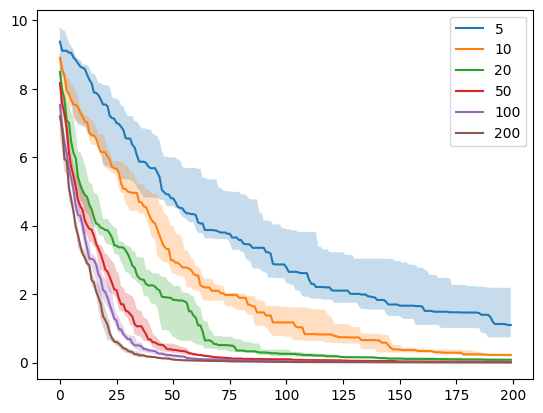

In [16]:
median_max = np.median(best_fitnesses, axis=1)
fit_75 = np.quantile(best_fitnesses, q=0.75, axis=1)
fit_25 = np.quantile(best_fitnesses, q=0.25, axis=1)

for i, n in enumerate(pop_sizes):
    plt.plot(np.arange(nbgen), median_max[i], label=str(n))
    plt.fill_between(np.arange(nbgen),
                     fit_25[i], fit_75[i], alpha=0.25, linewidth=0)
plt.legend()
plt.show()

#### Question 3.

Commentez et interprêtez vos résultats:
- Quelle est l'évolution de la meilleure fitness en fonction de la génération et pourquoi ?
- Quelle est l'évolution de la meilleure fitness en fonction de la taille de population et pourquoi ?

Si on suppose que le plus critique dans l'algorithme est le nombre d'appels à la fonction d'évaluation, quelle taille de population est la plus intéressante sur notre problème ?

Répondez directement dans la cellule Markdown ci-dessous:

-> Votre réponse ici <-

**Évolution de la fitness au fil des générations**  
La fitness diminue rapidement au début, puis se stabilise. Cela s’explique par une convergence progressive vers un optimum. La sélection par tournoi favorise les bons individus mais peut réduire la diversité, ce qui limite l’exploration tardive.

**Influence de la taille de population**  
Une population plus grande (jusqu’à 200) atteint une meilleure fitness finale, car elle maintient une diversité génétique plus élevée, évitant une convergence prématurée. À l’inverse, une petite population (5 ou 10) stagne rapidement sur des valeurs élevées.

**Choix de la taille si le nombre d’évaluations est critique**  
Le coût est proportionnel à `n × nbgen`. Un compromis est nécessaire : `n=50` donne une fitness proche de l’optimum par rapport à `n=200`. 

### 3.2. Sélection élitiste

#### Question 4.

Ce deuxième algorithme va à la place utiliser une sélection élitiste, et une construction un peu différente de la nouvelle population
Complétez la fonction ci-dessous qui définit un algorithme évolutionniste avec les caractéristiques suivantes:

- Opérateurs de croisement et de mutation: comme avant
- Opérateur de sélection: sélection élitiste (`selBest`)

Algorithme:
1. Clonage des `n` individus de la population
2. Croisement des `n` nouveaux individus avec probabilité `cxpb`
3. Mutation des `n` nouveaux individus avec probabilité `mutpb`
4. Evaluation des nouveaux individus
5. Concaténation des nouveaux individus avec les anciens (on a alors une population de taille 2n)
6. Sélection de `n` individus dans la population de taille `2n` pour former la nouvelle génération

In [17]:
def ea_elitist(n, nbgen, evaluate, ind_size=10, cxpb=0.5, mutpb=0.2):
    """Algorithme evolutionniste avec sélection élitiste

    Algorithme evolutionniste avec sélection élitiste.
    :param n: taille de la population
    :param nbgen: nombre de générations
    :param evaluate: la fonction d'évaluation
    :param ind_size: la taille des individus
    :param cxpb: la probabilité de croisement
    :param mutpb: la probabilité de mutation
    """

    # Enregistrement de la fonction de création d'individus et de population dans la toolbox
    toolbox.register("individual", tools.initRepeat, creator.Individual,
                     toolbox.attribute, n=ind_size)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    # Sélection par elitist n individu
    toolbox.register("select", tools.selBest)

    # Fonction d'évaluation
    toolbox.register("evaluate", evaluate)

    # La structure qui permet de stocker les statistiques
    logbook = tools.Logbook()

    # La structure permettant de récupérer le meilleur individu
    hof = tools.HallOfFame(1)

    # Initialise la population
    population = toolbox.population(n=n)

    # Evaluation des individus de la génération 0
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit

    # Pour enregistrer les statistiques de la génération 0
    hof.update(population)
    logbook.record(gen=0, best=hof[0].fitness.values[0])

    # On boucle sur le nombre de générations
    for g in range(1, nbgen):

        # 1. Clonage de la population pour créer les enfants
        offspring = list(map(toolbox.clone, population))

        # 2. Croisement des enfants avec une probabilité cxpb
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                # Modifie directement child1 et child2
                toolbox.mate(child1, child2)
                # Permet d'effacer les fitness des enfants après le croisement, car ils ont été modifiés
                del child1.fitness.values
                del child2.fitness.values

        # 3. Mutation des enfants avec une probabilité mutpb
        for mutant in offspring:
            if random.random() < mutpb:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # 4. Evaluation des individus de la nouvelle population
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # 5. Concatenation de la population et des enfants pour faire la sélection élitiste
        population += offspring

        # 6. Sélection des individus de la population pour créer la prochaine génération
        population = toolbox.select(population, n)

        # Pour enregistrer les statistiques de la génération g
        hof.update(population)
        logbook.record(gen=g, best=hof[0].fitness.values[0])

    return population, hof, logbook

#### Question 5.

Lancez les mêmes expériences que dans la question 2, cette fois-ci pour l'algorithme `ea_elitist`.

In [18]:
pop_sizes = [5, 10, 20, 50, 100, 200]
seeds = 10
nbgen = 200
cxpb = 0.5
mutpb = 0.5

best_fitnesses = np.zeros((len(pop_sizes), seeds, nbgen))

for i, n in enumerate(pop_sizes):

    print("EA Elitist: n=%d nbgen=%d,cxpb=%f, mutpb=%f" %
          (n, nbgen, cxpb, mutpb))

    for s in range(seeds):

        # Appel de l'algorithme évolutionniste avec sélection élitiste
        _, _, logbook = ea_elitist(n, nbgen, ackley, IND_SIZE, cxpb, mutpb)
        best_fitnesses[i, s, :] = logbook.select("best")
    print(best_fitnesses)

EA Elitist: n=5 nbgen=200,cxpb=0.500000, mutpb=0.500000
[[[ 9.95443892  9.95030312  9.87965217 ...  0.95698134  0.95698134
    0.95698134]
  [ 8.360171    8.360171    8.360171   ...  0.71714583  0.71714583
    0.71714583]
  [10.35802785  9.87230859  9.87230859 ...  1.94507993  1.94507993
    1.94507993]
  ...
  [ 9.80799374  9.77657063  9.77657063 ...  1.55051174  1.55051174
    1.55051174]
  [ 8.66783612  7.71787931  7.71787931 ...  1.41175171  1.41175171
    1.37800741]
  [ 8.99036577  8.95172787  8.95172787 ...  1.12770602  1.12770602
    1.0538902 ]]

 [[ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.          0.          0.         ...  0.          0.
    0.        ]
  ...
  [ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.          0.          0.         ...  0.          0.
    0.        ]
  [ 0.          0.          0.         ...  0.          0

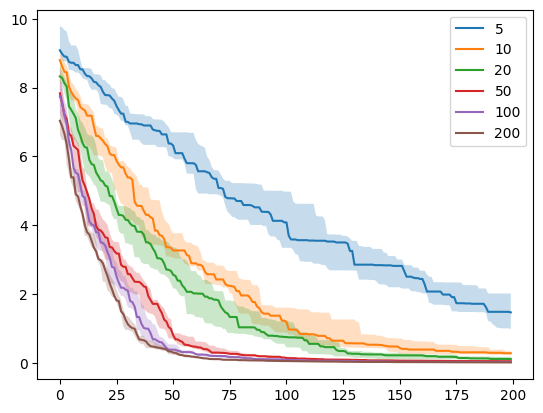

In [19]:
median_max = np.median(best_fitnesses, axis=1)
fit_75 = np.quantile(best_fitnesses, q=0.75, axis=1)
fit_25 = np.quantile(best_fitnesses, q=0.25, axis=1)

for i, n in enumerate(pop_sizes):
    plt.plot(np.arange(nbgen), median_max[i], label=str(n))
    plt.fill_between(np.arange(nbgen),
                     fit_25[i], fit_75[i], alpha=0.25, linewidth=0)
plt.legend()
plt.show()

#### Question 6.

Commentez et interprêtez vos résultats.
Est-ce qu'il y a des différences notables avec `ea_tournament`, pourquoi ?

Répondez directement dans la cellule Markdown ci-dessous:

-> Votre réponse ici <-
L’élitiste converge plus vite mais stagne sur des fitness moins bonnes car il perd la diversité. Le tournoi explore mieux et atteint des valeurs plus faibles. La différence vient d’une meilleure exploration du tournoi, cruciale sur la fonction d’Ackley (multi‑modale).

### 3.3. Implémentation de NSGA-II

Vous allez maintenant implémenter l'algorithme NSGA-II présenté en cours et l'appliquer sur une fonction de benchmark multi-objectifs qu'est la fonction de Fonseca et Fleming: https://en.wikipedia.org/wiki/Test_functions_for_optimization

L'algorithme NSGA-II fonctionne comme l'algorithme élitiste, mais comme cet algorithme est multi-objectif, il va falloir modifier plusieurs choses:
1. Les fitness ne sont plus composées d'un tuple de taille, et il s'agit d'un problème de double minimisation
2. Afficher l'évolution du meilleur individu n'a plus de sens, car il n'y a pas de meilleur individu mais un front de pareto

#### Question 7.

Pour le point numéro 1. ci-dessus, il va falloir redéfinir la fitness utilisée dans le type `Individual`. En vous inspirant de ce qu'on a fait dans l'exemple introductif:
- Définissez une nouvelle classe de fitness appelée `FitnessMinMin` correspondant à la minimisation de deux objectifs
- Définissez la classe `Individual2` avec cette nouvelle classe de fitness (on change son nom pour éviter tout conflit avec le code précédent)

In [21]:
creator.create("FitnessMinMin", base.Fitness, weights=(-1.0, -1.0))
creator.create("Individual2", list, fitness=creator.FitnessMinMin)

/Users/yuxiangzhang/Library/Python/3.9/lib/python/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMinMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/Users/yuxiangzhang/Library/Python/3.9/lib/python/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual2' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


Pour le point numéro 2. ci-dessus, on propose de caractérisez la performance d'une population non plus par son meilleur individu mais par son meilleur front de Pareto.

La qualité du front de Pareto est utilisée en calculant l'hypervolume à partir d'un point de référence.

La cellule ci-dessous montre comment calculer l'hypervolume associée à un ensemble de points formant le front de Pareto, et un point de référence.

Dans le cas de la fonction de Fonseca et Fleming, vous utiliserez le point (1, 1) comme point de référence.

In [22]:
from deap.tools._hypervolume import hv

hyperv = hv.hypervolume(
    [
        np.array([1, 0]),  # Les points sur le front de Pareto
        np.array([0.5, 0.5]),
        np.array([0, 1])
    ],
    np.array([2, 2])  # Le point de référence
)

print("Hypervolume: %f" % hyperv)

Hypervolume: 3.250000


#### Question 8.

Implémentez ci-dessous l'algorithme NSGA-II.

L'algorithme NSGA-II fonctionne sinon comme l'algorithme élitiste, à la différence de sa fonction d'évaluation (`selNSGA2`) et de son caractère multi-objectif.

Le hall-of-fame est remplacé par un front de Pareto qui est mis-à-jour. Le code pour la construction et la mise à jour du front de Pareto vous est donné.

In [23]:
def ea_nsga2(n, nbgen, evaluate, ref_point=np.array([1, 1]), ind_size=10, cxpb=0.5, mutpb=0.2):
    """Algorithme evolutionniste avec sélection par NSGA-II

    Algorithme evolutionniste avec sélection par NSGA-II.
    :param n: taille de la population
    :param nbgen: nombre de générations
    :param evaluate: la fonction d'évaluation
    :param ref_point: le point de référence pour le calcul de l'hypervolume
    :param ind_size: la taille des individus
    :param cxpb: la probabilité de croisement
    :param mutpb: la probabilité de mutation
    """

    # Enregistrement de la fonction de création d'individus et de population dans la toolbox
    toolbox.register("individual2", tools.initRepeat, creator.Individual2,
                     toolbox.attribute, n=ind_size)
    toolbox.register("population2", tools.initRepeat, list, toolbox.individual2)

    # Sélection par nsga
    toolbox.register("select", tools.selNSGA2)

    # Fonction d'évaluation
    toolbox.register("evaluate", evaluate)

    # La structure qui permet de stocker les statistiques
    logbook = tools.Logbook()

    # La structure permettant de récupérer le front de pareto
    paretofront = tools.ParetoFront()

    # Initialise la population
    population = toolbox.population2(n=n)

    # Evaluation des individus de la génération 0
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit

    # Pour enregistrer les statistiques de la génération 0
    paretofront.update(population)
    pointset = [np.array(ind.fitness.getValues()) for ind in paretofront]
    hypervolume = hv.hypervolume(pointset, ref_point)
    logbook.record(gen=0, hypervolume=hypervolume)

    # On boucle sur le nombre de générations
    for g in range(1, nbgen):

        # Mêmes étapes que pour l'algorithme élitiste
        # 1. Clonage de la population pour créer les enfants
        offspring = list(map(toolbox.clone, population))

        # 2. Croisement des enfants avec une probabilité cxpb
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        # 3. Mutation des enfants avec une probabilité mutpb
        for mutant in offspring:
            if random.random() < mutpb:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # 4. Evaluation des individus de la nouvelle population
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # 5. Concatenation de la population et des enfants pour faire la sélection élitiste
        population += offspring

        # 6. Sélection des individus de la population pour créer la prochaine génération
        population = toolbox.select(population, n)

        # Pour enregistrer les statistiques de la génération g
        paretofront.update(population)
        pointset = [np.array(ind.fitness.getValues()) for ind in paretofront]
        hypervolume = hv.hypervolume(pointset, ref_point)
        logbook.record(gen=g, hypervolume=hypervolume)

    return population, paretofront, logbook

#### Question 9.

A nouveau, étudiez l'effet de la taille de population. La population de 200 peut prendre beaucoup de temps, vous pouvez vous limiter à 100 pour cette question.

In [25]:
from deap.benchmarks import fonseca


pop_sizes = [5, 10, 20, 50, 100, 200]
seeds = 10
nbgen = 200
cxpb = 0.5
mutpb = 0.5

# point ref pour fonseca
ref_point = np.array([1, 1])

best_hypervolumes = np.zeros((len(pop_sizes), seeds, nbgen))

for i, n in enumerate(pop_sizes):

    print("EA Elitist: n=%d nbgen=%d,cxpb=%f, mutpb=%f" %
          (n, nbgen, cxpb, mutpb))

    for s in range(seeds):

        # Appel de l'algorithme évolutionniste avec sélection par NSGA-II
        _, _, logbook = ea_nsga2(n, nbgen, fonseca, ref_point, IND_SIZE, cxpb, mutpb)
        best_hypervolumes[i, s, :] = logbook.select("hypervolume")
    print(best_hypervolumes)

EA Elitist: n=5 nbgen=200,cxpb=0.500000, mutpb=0.500000
[[[2.25681518e-13 2.25681518e-13 2.25681518e-13 ... 1.98249690e-01
   1.98249690e-01 1.98249690e-01]
  [7.70258957e-14 7.70258957e-14 7.78621019e-14 ... 1.82262530e-01
   1.82262530e-01 1.82262530e-01]
  [4.53711719e-09 7.26792847e-09 7.26792847e-09 ... 7.99498121e-02
   7.99498121e-02 7.99498121e-02]
  ...
  [3.12590870e-07 4.73938820e-04 4.73938820e-04 ... 1.28492893e-01
   1.28492893e-01 1.28492893e-01]
  [8.58896100e-12 2.53590244e-11 4.64444624e-04 ... 2.22226942e-01
   2.22226942e-01 2.22226942e-01]
  [5.45716155e-06 2.09592749e-02 2.25680864e-02 ... 1.87591966e-01
   1.87591966e-01 1.87591966e-01]]

 [[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   0.00000000e+00 0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   0.00000000e+00 0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   0.00000000e+00 0.00000000e+00]
  ...
  [0.00000000e+00 0.0

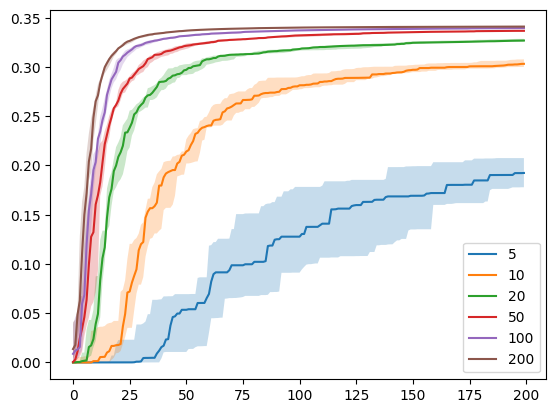

In [26]:
median_max = np.median(best_hypervolumes, axis=1)
fit_75 = np.quantile(best_hypervolumes, q=0.75, axis=1)
fit_25 = np.quantile(best_hypervolumes, q=0.25, axis=1)

for i, n in enumerate(pop_sizes):
    plt.plot(np.arange(nbgen), median_max[i], label=str(n))
    plt.fill_between(np.arange(nbgen),
                     fit_25[i], fit_75[i], alpha=0.25, linewidth=0)
plt.legend()
plt.show()

#### Question 10.

Vous avez dû remarquer que NSGA-II était beaucoup plus lent que les deux autres algorithmes.

Pour tenter d'expliquer cette observation, donnez des estimations des complexités des trois méthodes d'évaluation: par tournoi, élitiste, et NSGA2, en fonction de `n` et de `k` (pour les tournois).

-> Votre réponse ici <-
- **Tournoi** : sélection en `O(k·n)` (k constant), puis croisement/mutation `O(n)`, évaluation `O(n)`. Complexité linéaire `O(n)` par génération.
- **Élitiste (μ+λ)** : tri de `2n` individus pour sélectionner les `n` meilleurs → `O(n log n)` par génération.
- **NSGA‑II** : tri de Pareto (non‑dominated sorting) et calcul des distances de crowding. Pour `m` objectifs (ici `m=2`), la complexité est `O(m·n²) = O(n²)` par génération, soit quadratique. C’est pourquoi NSGA‑II devient beaucoup plus lent que les deux autres quand `n` augmente.

## 4. Application à un cas concret

L'objectif de la fin de ce TME est d'utiliser les algorithmes évolutionnistes implémentés pour apprendre des politiques. 

On cherche à apprendre la politique d'un bras simulé en 2D. Les paramètres soumis à l'optimisation par algorithme évolutionniste seront les paramètres d'un réseau de neurones artificiel (Multi Layer Perceptron) calculant l'action à effectuer en fonction de l'état du bras. Le bras comporte deux articulations. L'action correspond au couple exercé sur chaque articulation (donc de dimension 2 pour 2 articulations) et l'état du bras correspond à la position angulaire et la vitesse angulaire des deux articulations (donc de dimension 4 pour 2 articulations).

Les annexes pour cette partie (et la suivante) contiennent:
- `nn.py`: le code associé à une politique représentée sous forme de réseaux de neurones: **NE PAS MODIFIER**
- `arm.py`: le code utilisé pour simuler et afficher la trajectoire d'un bras en 2D: **NE PAS MODIFIER**

Un exemple d'utilisation de ces deux annexes est donné dans la cellule suivante:

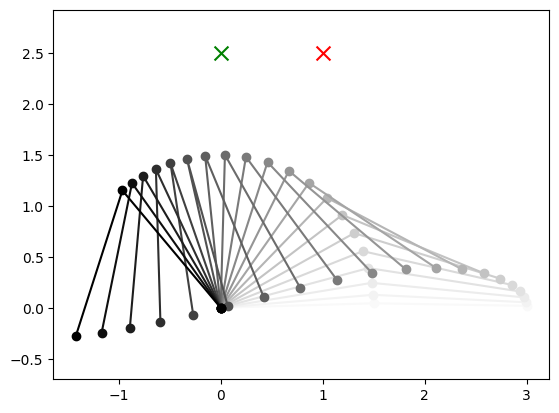

In [30]:
import arm
from nn import SimpleNeuralControllerNumpy

d_state = 4
d_action = 2
mlp_depth = 2
mlp_width = 5

# Environnement = bras articulé (vous pourrez garder ces mêmes paramètres pour vos expériences)
env = arm.Arm([1.5, 1.5], obstacle_position=[
              1., 2.5], target_position=[0., 2.5])

# Initialisation d'un NN pour la politique qui controle le bras
policy = SimpleNeuralControllerNumpy(d_state, d_action, mlp_depth, mlp_width)

# On peut utiliser un génotype pour modifier les paramètres du NN
genotype_aleatoire = np.random.randn(policy.n_weights)
policy.set_parameters(genotype_aleatoire)

# Initialisation de l'environnement
state, joints_xy, (d_target, d_obstacle), done = env.reset()

# On simule une trajectoire de 20 steps avec cette politique et cet environnement
nbstep = 20

# Pour sauvegarder la trajectoire
traj = np.zeros((nbstep+1, env.n_dofs+1, 2))
traj[0] = joints_xy

for step in range(nbstep):
    action = policy.predict(state) / 2
    state, joints_xy, (d_target, d_obstacle), done = env.step(action)

    # Sauvegarde
    traj[step+1] = joints_xy

# Affichage de la trajectoire
env.display_trajectory(traj)

### 4.1. Version mono-objectif

Dans la version mono-objectif, on considère que la récompense à un instant $t$ est de la distance euclidienne à la position cible du bout du bras (qu'on peut récupérer dans `joints_xy`). La fitness de la polique correspond à la somme au cours du temps de cette récompense. 

#### Question 11.

En vous inspirant du code précédent, implémentez une fonction `eval_nn_mono` qui servira à évaluer un génotype donner dans cet environnement.

Cette fonction d'évaluation devra prendre en entrée le génotype et calculer la fitness correspondante telle que définie ci-dessus. Dans DEAP, la fonction d'évaluation doit retourner un tuple, même dans le cas mono-objectif. Votre fonction devra donc retourner quelque chose comme:

    return (fitness,)

In [44]:
def eval_nn_mono(genotype, render=False, nbstep=20):
    """Evaluation d'une politique parametrée par le génotype

    Evaluation d'une politique parametrée par le génotype
    :param genotype: le paramètre de politique à évaluer, np.array de dimension IND_SIZE
    :param render: affichage du bras
    :param nbstep: durée d'une évaluation
    """

    nn = SimpleNeuralControllerNumpy(4, 2, 2, 5)
    nn.set_parameters(genotype)

    avg_to_target = 0

    # Simulation de la trajectoire avec la politique paramétrée par le génotype
    state, joints_xy, (d_target, d_obstacle), done = env.reset()

    # stocker la trajectoire uniquement si render=True
    traj = None
    if render:
        traj = np.zeros((nbstep+1, env.n_dofs+1, 2))
        traj[0] = joints_xy

    for step in range(nbstep):
        action = nn.predict(state) / 2
        state, joints_xy, (d_target, d_obstacle), done = env.step(action)
        avg_to_target += d_target

        if render:
            traj[step+1] = joints_xy

    # Affichage de la trajectoire si demandé
    if render:
        env.display_trajectory(traj)

    return (avg_to_target,)

#### Question 12.

Utilisez cette nouvelle fonction d'évaluation avec l'algorithme `ea_elitist` utilisé précédemment. Vous tracerez dans le notebook l'évolution des fitness. Les calculs étant plus longs, vous pouvez vous limiter à trois tailles de population (par exemple [10, 50, 200]) et une seule seed.

In [45]:
pop_sizes = [10, 50, 200]
seeds = 1
nbgen = 200
cxpb = 0.5
mutpb = 0.5

nn = SimpleNeuralControllerNumpy(4,2,2,5)
ind_size = len(nn.get_parameters())

best_fitnesses = np.zeros((len(pop_sizes), seeds, nbgen))
hofs = []

for i, n in enumerate(pop_sizes):
    hofs.append([])

    print("EA Elitist: n=%d nbgen=%d,cxpb=%f, mutpb=%f" %
          (n, nbgen, cxpb, mutpb))

    for s in range(seeds):

        # Appel de l'algorithme évolutionniste élitiste
        population, hof, logbook = ea_elitist(n, nbgen, eval_nn_mono, ind_size=ind_size, cxpb=cxpb, mutpb=mutpb)

        best_fitnesses[i, s, :] = logbook.select("best")
        hofs[-1].append(hof)

EA Elitist: n=10 nbgen=200,cxpb=0.500000, mutpb=0.500000
EA Elitist: n=50 nbgen=200,cxpb=0.500000, mutpb=0.500000
EA Elitist: n=200 nbgen=200,cxpb=0.500000, mutpb=0.500000


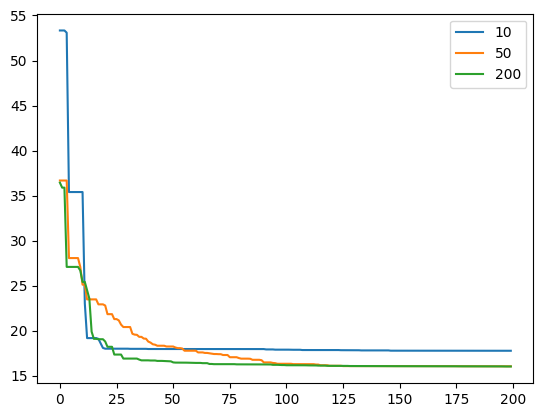

In [46]:
median_max = np.median(best_fitnesses, axis=1)
fit_75 = np.quantile(best_fitnesses, q=0.75, axis=1)
fit_25 = np.quantile(best_fitnesses, q=0.25, axis=1)

for i, n in enumerate(pop_sizes):
    plt.plot(np.arange(nbgen), median_max[i], label=str(n))
    plt.fill_between(np.arange(nbgen),
                     fit_25[i], fit_75[i], alpha=0.25, linewidth=0)
plt.legend()
plt.show()

### 4.2. Version multi-objectifs

En multi-objectif, nous nous proposons de chercher à atteindre la position cible tout en contournant la position de l'obstacle. Nous ne savons pas a priori à quel point le bras doit passer loin de l'obstacle et donc différentes solutions sont intéressantes à explorer (certaines esquivant l'obstacle de peu, et d'autres le contournant très largement).

#### Question 13.

Implémentez une nouvelle fonction d'évaluation qui calcule cette fois-ci deux informations: 
- l'intégrale de la distance avec la position cible tout au long de la trajectoire
- la distance minimale avec la position de l'obstacle au cours de la trajectoire

Pour que le problème soit encore un problème de double minimisation, au lieu de retourner la distance minimale à l'obstacle, on va retourner l'opposé de cette valeur. Ca permet de réutiliser directement la fonction `ea_nsga2` implémentée précedemment, qui fonctionnait en double minimisation.

In [47]:
def eval_nn_multi(genotype, render=False, nbstep=20):
    """Evaluation d'une politique parametrée par le génotype

    Evaluation d'une politique parametrée par le génotype
    :param genotype: le paramètre de politique à évaluer, np.array de dimension IND_SIZE
    :param render: affichage du vras
    :param nbstep: durée d'une évaluation
    """

    nn = SimpleNeuralControllerNumpy(4, 2, 2, 5)
    nn.set_parameters(genotype)

    avg_to_target = 0
    min_to_obstacle = float('inf')

    # Simulation de la trajectoire avec la politique paramétrée par le génotype
    state, joints_xy, (d_target, d_obstacle), done = env.reset()

    # Stockage de la trajectoire si affichage demandé
    traj = None
    if render:
        traj = np.zeros((nbstep+1, env.n_dofs+1, 2))
        traj[0] = joints_xy

    for step in range(nbstep):
        action = nn.predict(state) / 2
        state, joints_xy, (d_target, d_obstacle), done = env.step(action)

        avg_to_target += d_target
        if d_obstacle < min_to_obstacle:
            min_to_obstacle = d_obstacle

        if render:
            traj[step+1] = joints_xy

    if render:
        env.display_trajectory(traj)

    return (avg_to_target, -min_to_obstacle)  # Le signe moins est volontaire (cf énoncé)

#### Question 14.

Appliquez NSGA2 à ce problème d'optimisation multi-objectifs.

Pour le calcul de l'hypervolume, on utilisera maintenant comme point de référence (100, 0).

Utilisez les mêmes tailles de population que pour la partie 4.

In [49]:
pop_sizes = [10, 50,200]
seeds = 1
nbgen = 200
cxpb = 0.5
mutpb = 0.5

nn = SimpleNeuralControllerNumpy(4,2,2,5)
ind_size = len(nn.get_parameters())

best_hypervolumes = np.zeros((len(pop_sizes), seeds, nbgen))
paretos = []

for i, n in enumerate(pop_sizes):
    paretos.append([])

    print("EA NSGA2: n=%d nbgen=%d,cxpb=%f, mutpb=%f" %
          (n, nbgen, cxpb, mutpb))

    for s in range(seeds):

        # Appel de l'algorithme évolutionniste avec sélection par NSGA-II
        population, paretofront, logbook = ea_nsga2(
            n, nbgen, eval_nn_multi,
            ref_point=np.array([100, 0]),  # point de référence pour l'hypervolume
            ind_size=ind_size, cxpb=cxpb, mutpb=mutpb
        )

        best_hypervolumes[i, s, :] = logbook.select("hypervolume")
        paretos[-1].extend(paretofront)

EA NSGA2: n=10 nbgen=200,cxpb=0.500000, mutpb=0.500000
EA NSGA2: n=50 nbgen=200,cxpb=0.500000, mutpb=0.500000
EA NSGA2: n=200 nbgen=200,cxpb=0.500000, mutpb=0.500000


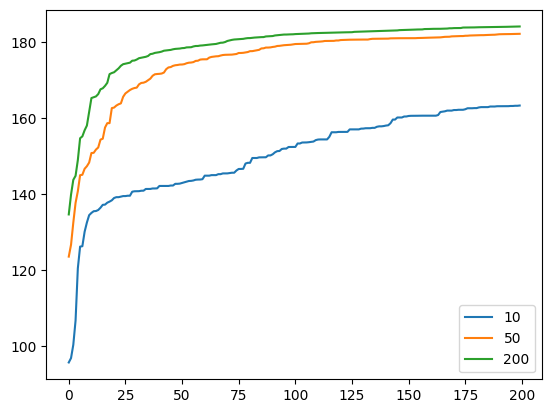

In [50]:
nbgen = 200
pop_sizes = [10, 50, 200]

median_max = np.median(best_hypervolumes, axis=1)
fit_75 = np.quantile(best_hypervolumes, q=0.75, axis=1)
fit_25 = np.quantile(best_hypervolumes, q=0.25, axis=1)

for i, n in enumerate(pop_sizes):
    plt.plot(np.arange(nbgen), median_max[i], label=str(n))
    plt.fill_between(np.arange(nbgen),
                     fit_25[i], fit_75[i], alpha=0.25, linewidth=0)
plt.legend()
plt.show()

### 4.3. Analyse des résultats

La figure suivante permet d'afficher sur la même figure les performances des solutions trouvées par les deux algorithmes:
- Les points correspondent aux fronts de pareto obtenus avec NSGA2
- Les croix correspondent aux solutions trouvées avec l'algorithme mono-objectif, qu'on évalue cette fois avec les deux objectifs

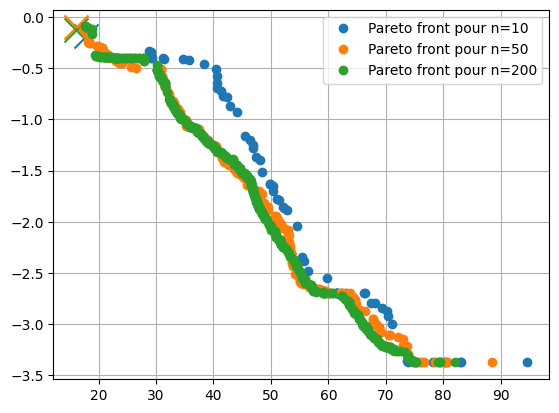

In [51]:
fig, ax = plt.subplots()
for i, n in enumerate(pop_sizes):
    points = np.array([p.fitness.values for p in paretos[i]])
    ax.plot(points[:, 0], points[:, 1], 'o',
            label="Pareto front pour n="+str(n))
ax.legend()
ax.grid(True)
ax.set_axisbelow(True)

for i, n in enumerate(pop_sizes):
    best_genotype = hofs[i][0][0]
    x, y = eval_nn_multi(best_genotype)
    plt.scatter([x], [y], marker='x', s=300)
plt.legend()
plt.show()

#### Question 15.

Commentez les résultats représentés sur cette figure.

L'algorithme élitiste trouve-t'il toujours une meilleure solution que NSGA2 pour son objectif unique ? Pourquoi ?

-> Votre réponse ici <-
Les points (Pareto fronts) montrent que NSGA‑II trouve un ensemble de solutions non dominées pour chaque taille de population.

Plus la population est grande (n=200), plus le front de Pareto s’étend vers des distances cumulées faibles (meilleure optimisation de l’objectif principal) et vers des marges de sécurité élevées.

Les croix (solutions de l’algorithme élitiste mono‑objectif) se situent toujours sur le côté gauche du graphique (distance cumulée très faible) mais avec une distance minimale à l’obstacle très petite (point très bas sur l’axe des ordonnées, car -min est faible → obstacle très proche).

L’algorithme élitiste trouve‑t‑il toujours une meilleure solution que NSGA‑II pour son objectif unique ?

Oui, pour l’objectif unique “minimiser la distance cumulée à la cible”, l’algorithme élitiste converge généralement vers une valeur plus faible que celle obtenue par NSGA‑II.

Pourquoi ?
Parce que l’élitiste optimise un seul critère sans se soucier de l’autre. Il peut ainsi se concentrer entièrement sur la réduction de la distance à la cible, quitte à passer très près de l’obstacle. NSGA‑II, en revanche, doit maintenir un front de solutions qui explorent le compromis entre les deux objectifs. Par construction, il ne peut pas sacrifier complètement le second objectif, donc la meilleure solution sur le premier objectif dans son front est légèrement moins bonne que celle obtenue par l’optimisation mono‑objectif pure.

#### Quesiton 16.

La fonction `eval_nn_multi` avec l'argument `render=True` permet d'afficher la trajectoire correspondant à l'individu qu'on évalue.

Utilisez cette fonction pour afficher différentes politiques sur le front de pareto obtenu avec NSGA2 pour la population de taille maximale que vous avez testée.
Ce front de pareto peut être de grande taille (plusieurs centaines de solutions) donc n'afficher pas que les quelques premiers, essayez d'aller afficher environ 5 solutions réparties uniformément dans le front de pareto pour bien observer les différences de politiques.

Commentez les trajectoires obtenues.

Solution 1 — Fitness : (np.float64(17.582425398885615), np.float64(-0.09326714479188358))


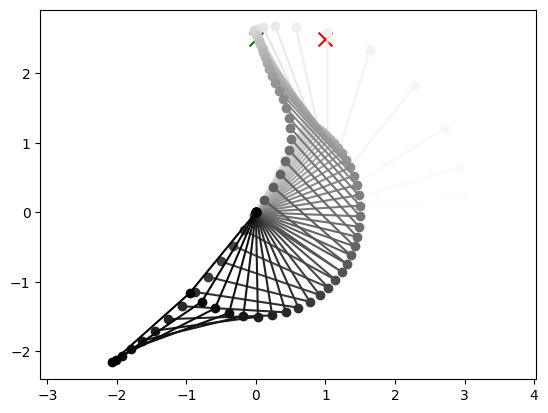

Solution 2 — Fitness : (np.float64(34.92109837190772), np.float64(-1.0091007450652714))


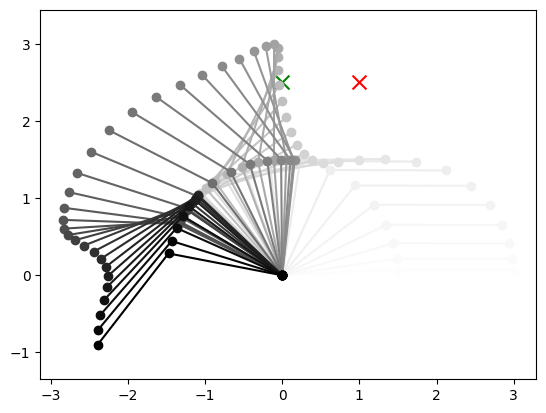

Solution 3 — Fitness : (np.float64(46.89157973774423), np.float64(-1.695888732812548))


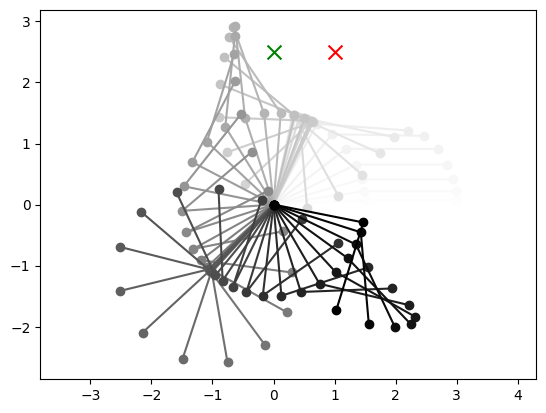

Solution 4 — Fitness : (np.float64(55.413342082029786), np.float64(-2.5508475442605527))


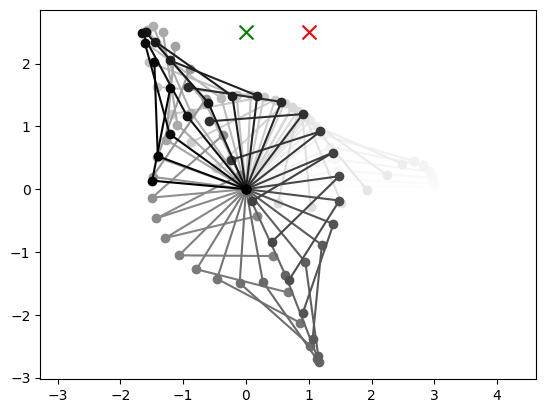

Solution 5 — Fitness : (np.float64(82.08818465013003), np.float64(-3.3744195468891633))


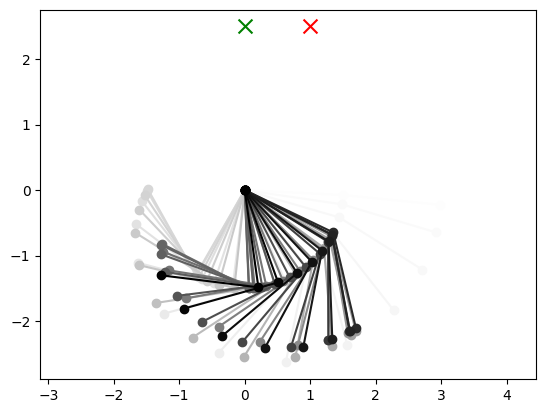

In [52]:
# Récupérer le front de Pareto pour n=200 (dernier élément de la liste)
pareto_front_200 = paretos[-1]

# Trier selon le premier objectif (distance cumulée à la cible)
pareto_sorted = sorted(pareto_front_200, key=lambda ind: ind.fitness.values[0])

# Sélectionner 5 indices uniformément répartis
n_solutions = 5
indices = np.linspace(0, len(pareto_sorted)-1, n_solutions, dtype=int)
selected_solutions = [pareto_sorted[i] for i in indices]

# Afficher chaque solution avec render=True
for i, sol in enumerate(selected_solutions):
    print(f"Solution {i+1} — Fitness : {sol.fitness.values}")
    eval_nn_multi(sol, render=True, nbstep=50)

Ces cinq solutions sont toutes non dominées : elles appartiennent au front de Pareto de l’optimisation multi-objectifs.

Solution 1 : (17.58, -0.093) → distance cumulée très faible (le bras va vite à la cible) mais distance minimale à l’obstacle = 0.093 (très proche). Risque de collision élevé.

Solution 2 : (34.92, -1.01) → compromis : la trajectoire est un peu plus longue, mais l’obstacle est déjà à 1 unité de distance.

Solution 3 : (46.89, -1.70) → distance à l’obstacle 1.70, pour un chemin modérément allongé.

Solution 4 : (55.41, -2.55) → l’obstacle est nettement plus loin (2.55), mais la distance parcourue augmente.

Solution 5 : (82.09, -3.37) → la plus grande marge de sécurité (obstacle à 3.37), au prix d’une trajectoire beaucoup plus longue.

Interprétation :
Plus on veut s’éloigner de l’obstacle (grande valeur de -min_to_obstacle, donc grande distance réelle), plus la distance cumulée à la cible augmente. Il y a un compromis entre efficacité (aller droit au but) et sécurité (contourner l’obstacle). Ces solutions couvrent tout l’éventail des possibilités, depuis l’approche risquée jusqu’à l’évitement très prudent.